In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [17]:
import sys
sys.path.append("C:\\Users\\rolny\\Desktop\\Shiro\\lecture01\\note")
from helper import get_distance

In [18]:
stations = pd.read_csv("../data/hubway_stations.csv")
trips = pd.read_csv("../data/hubway_trips.csv")

In [19]:
stations.head()

,id,terminal,station,municipal,lat,lng,status
0,3,B32006,Colleges of the Fenway,Boston,42.340021,-71.100812,Existing
1,4,C32000,Tremont St. at Berkeley St.,Boston,42.345392,-71.069616,Existing
2,5,B32012,Northeastern U / North Parking Lot,Boston,42.341814,-71.090179,Existing
3,6,D32000,Cambridge St. at Joy St.,Boston,42.361285,-71.065140,Existing
4,7,A32000,Fan Pier,Boston,42.353412,-71.044624,Existing


terminal: điểm cuối/ trạm cuối
station: địa điểm ga tàu
municipal: khu vực, thành phố
lat: vĩ độ / lng: kinh độ 
status: trạng thái ga tàu (đang hoạt động không)
-> id: mã ga tàu 

In [20]:
trips.head()

,Unnamed: 0,hubway_id,duration,start_date,strt_statn,end_date,end_statn,zip_code,birth_date,gender
0,426015,482077,675,8/18/2012 19:48:00,8.0,8/18/2012 20:00:00,8.0,'02134,1983.0,Male
1,193080,220612,204,4/26/2012 18:14:00,31.0,4/26/2012 18:17:00,64.0,'02210,1953.0,Male
2,530051,598721,888,9/23/2012 09:26:00,39.0,9/23/2012 09:41:00,39.0,'02118,1985.0,Male
3,484594,547645,526,9/8/2012 12:55:00,88.0,9/8/2012 13:04:00,72.0,'02139,1985.0,Male
4,291265,332163,554,6/21/2012 18:53:00,47.0,6/21/2012 19:02:00,54.0,'02113,1986.0,Female


hubway_id: mã chuyến đi
duration: khoảng cách chuyến đi
strt_statn: ga bắt đầu / end_statn: ga kết thúc
zip-code: mã bưu chính người mua vé
birth-date: năm sinh -> tính tuổi
gender: giới tính 

In [21]:
#Getting the data types of each column in the stations data
stations.dtypes

id             int64
terminal         str
station          str
municipal        str
lat          float64
lng          float64
status           str
dtype: object

In [22]:
#Getting the data types of each column in the trips data
trips.dtypes

Unnamed: 0      int64
hubway_id       int64
duration        int64
start_date        str
strt_statn    float64
end_date          str
end_statn     float64
zip_code          str
birth_date    float64
gender            str
dtype: object

In [23]:
stations.describe()

,id,lat,lng
count,142.000000,142.000000,142.000000
mean,74.323944,42.354820,-71.089087
std,41.389098,0.020089,0.027111
min,3.000000,42.309467,-71.146452
25%,39.250000,42.341652,-71.113183
50%,74.500000,42.353373,-71.089191
75%,109.750000,42.366265,-71.065210
max,145.000000,42.404490,-71.035705


In [24]:
trips.describe()

,Unnamed: 0,hubway_id,duration,strt_statn,end_statn,birth_date
count,210239.000000,210239.000000,2.102390e+05,210239.000000,210239.000000,210239.000000
mean,283491.142771,321401.542806,7.794459e+02,36.727567,36.662261,1976.285594
std,153204.497985,173059.875974,1.349006e+04,18.592716,18.551934,11.002281
min,0.000000,8.000000,0.000000e+00,3.000000,3.000000,1932.000000
25%,153899.000000,174103.000000,3.460000e+02,22.000000,22.000000,1969.000000
50%,280081.000000,319856.000000,5.320000e+02,38.000000,38.000000,1979.000000
75%,414740.000000,469290.000000,8.280000e+02,50.000000,50.000000,1985.000000
max,549285.000000,620312.000000,5.351083e+06,98.000000,98.000000,1995.000000


DATA PROCESSING

In [25]:
#tổng số dòng null trong tưng cột của stations
stations.isnull().sum()

id           0
terminal     0
station      0
municipal    0
lat          0
lng          0
status       0
dtype: int64

In [26]:
#xóa dòng có ít nhất một giá trị null trong stations
#nên kiêm tra trước khi xóa
stations.dropna(axis=0, inplace=True)

In [27]:
trips.isnull().sum()

Unnamed: 0    0
hubway_id     0
duration      0
start_date    0
strt_statn    0
end_date      0
end_statn     0
zip_code      0
birth_date    0
gender        0
dtype: int64

In [28]:
trips.dropna(axis=0, inplace=True)

In [29]:
#tạo cột mới tính tuổi của từng rider
trips["age"] = 2021.0 - trips["birth_date"].values

#xóa cột birth_date
trips.drop('birth_date', axis=1, inplace=True)

### **EXPLORATORY DATA ANALYSIS (EDA)** ###

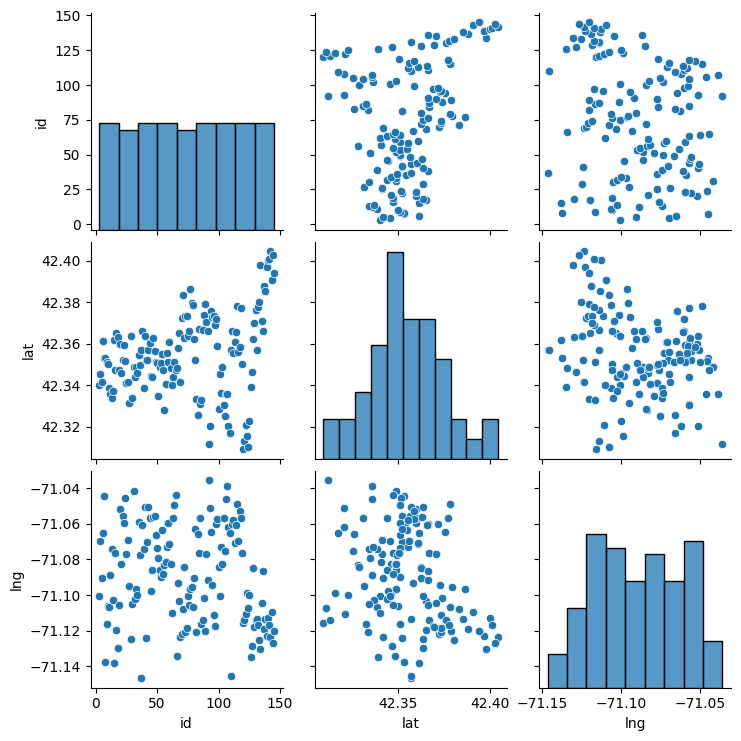

In [30]:
sns.pairplot(stations)

### Nhận xét: ###
- các biểu đồ histogram: 
    + biểu đồ id gần như phẳng, các giá trị trải đều từ 0 - 150: đây là số thứ tự tăng dần, biểu thị là mã định danh
    + biểu đồ lat tập trung nhiều ở giá trị ~ 42 (có thể các trạm nằm trên cùng một vĩ tuyến) 
    + biểu đồ lng không điểm tập trung nổi bật, sắp xếp ngẫu nhiên

- Các biểu đồ scatter:
    + các điểm dữ liệu không có cấu trúc, đặt ngẫu nhiên => không tạo mối quan hệ với các cột khác

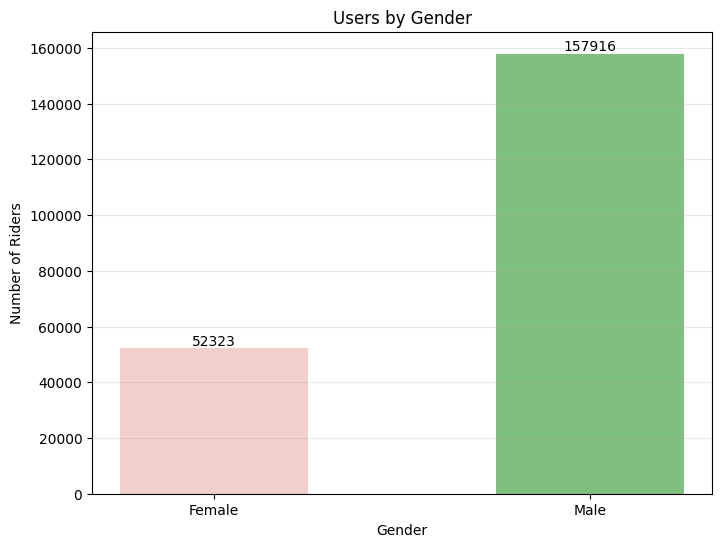

In [31]:
gender_counts = np.unique(trips['gender'].values, return_counts=True)

'''tham số return_counts: đếm số lần xuất hiện của từng giá trị duy nhất 
khi dùng unique, kết quả trả về: array(['Female', 'Male'])
khi dùng tham số return_counts: (array(['Female', 'Male']), array([số_lượng_Female, số_lượng_Male]))
nếu không có tham số đó thì mặc định là false: chỉ hiện kết quả unique và dtype của cột'''

fig, ax = plt.subplots(1,1, figsize=(8,6)) 
#tạo một figure (khung biểu đồ) 
#và một axes (trục biểu đồ) với 1 hàng và 1 cột, kích thước 8x6 inch

ax.bar(range(2), width=0.5, height=gender_counts[1], color=['#e4a199', 'green'], alpha=0.5)
'''range(2) tạo một dãy số từ 0 đến 1 (tương ứng với hai giới tính), 
có thể dùng [1.5, 2.5] để đặt cột ở vị trí 1.5 và 2.5 trên trục x,
width=0.5 đặt độ rộng của mỗi cột là 0.5,
height=gender_counts[1] sử dụng số lượng của mỗi giới tính làm chiều cao của cột,
color=['#e4a199', 'green'] đặt màu sắc cho mỗi cột,
alpha=0.5 làm cho các cột có độ trong suốt 50%'''

ax.set_xticks(range(2)) #đặt vị trí của các nhãn trên trục x tại 0 và 1
ax.set_xticklabels(gender_counts[0])
#đặt nhãn cho mỗi cột dựa trên giá trị duy nhất của giới tính

ax.set_title("Users by Gender") #đặt tiêu đề cho biểu đồ

#thêm nhãn cho trục x và trục y
ax.set_xlabel('Gender')
ax.set_ylabel('Number of Riders')


for i, count in enumerate(gender_counts[1]):
    ax.text(
        i, #vị trí của cột trên trục x
        count, #vị trí của nhãn trên trục y, đặt ở đỉnh của cột
        str(count), #nội dung của nhãn, chuyển số lượng thành chuỗi để hiển thị
        ha='center', #căn chỉnh ngang của nhãn, đặt ở giữa cột
        va='bottom' #căn chỉnh dọc của nhãn, đặt ở dưới đỉnh của cột
    )

ax.grid(axis='y', alpha=0.3)

### Nhận xét: ###
- Bikers chủ yếu là nam

### cấu trúc của biểu đồ ###
Figure

        └── Axes

                ├── trục x

                ├── trục y

                ├── tiêu đề

                ├── nhãn trục

                └── dữ liệu được vẽ
      

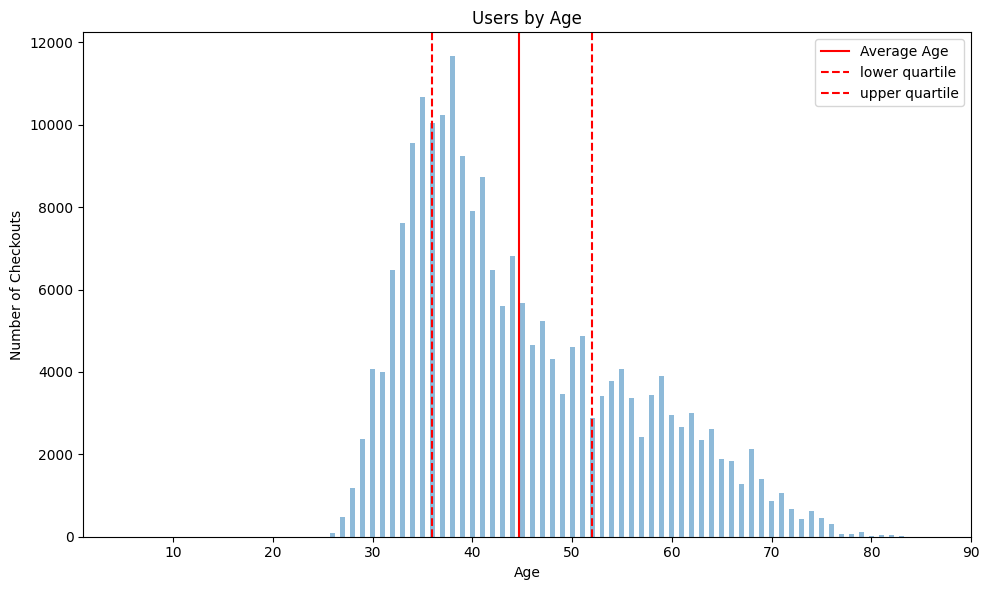

In [32]:
fig, ax = plt.subplots(1,1, figsize=(10,6))
age_counts= np.unique(trips['age'].values, return_counts=True)
ax.bar(age_counts[0], width=0.5, align='center', height=age_counts[1], alpha=0.5)
ax.axvline(x=np.mean(trips['age'].values), color='red', label='Average Age')
ax.axvline(x=np.percentile(trips['age'].values, 25), color='red', linestyle='--', label='lower quartile')
ax.axvline(x=np.percentile(trips['age'].values, 75), color='red', linestyle='--', label='upper quartile')
ax.set_xlim([1, 90])
ax.set_xlabel('Age')
ax.set_ylabel('Number of Checkouts')
ax.legend() #hiển thị chú thích cho các đường thẳng dọc
ax.set_title('Users by Age')
plt.tight_layout() #tự động điều chỉnh khoảng cách giữa các phần tử trong biểu đồ để tránh bị chồng lên nhau

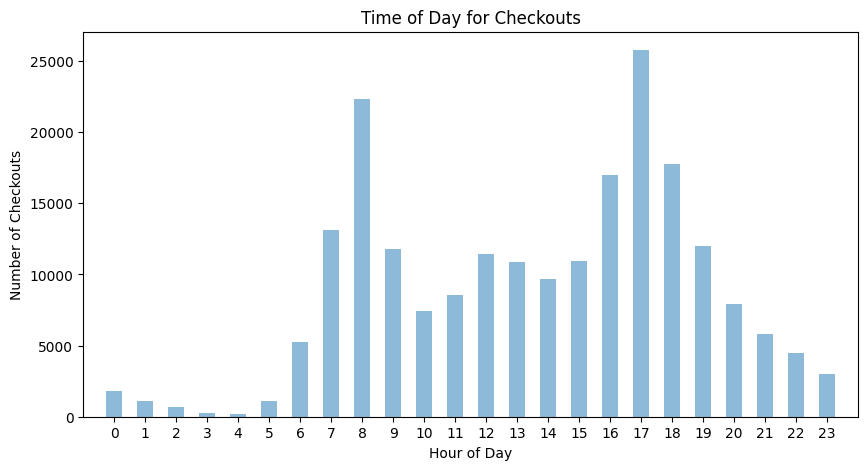

In [33]:
check_out_hours = trips['start_date'].apply(lambda s:int(s[-8:-6]))
'''lấy ra giờ từ chuỗi start_date bằng cách sử dụng slicing để lấy hai ký tự cuối cùng trước dấu ":"
và chuyển chúng thành số nguyên bằng hàm int()
ví dụ: nếu start_date là "2021-01-01 08:30:00", thì s[-8:-6] sẽ lấy ra "08" 
và int("08") sẽ trả về 8'''

check_out_counts = np.unique(check_out_hours, return_counts=True)

fig, ax = plt.subplots(1,1, figsize=(10,5))
ax.bar(check_out_counts[0], width=0.5, align='center', height=check_out_counts[1], alpha=0.5)
ax.set_xlim([-1, 24])
ax.set_xticks(range(24)) #đặt vị trí của các nhãn trên trục x từ 0 đến 23
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Checkouts')
ax.set_title('Time of Day for Checkouts')
plt.show()

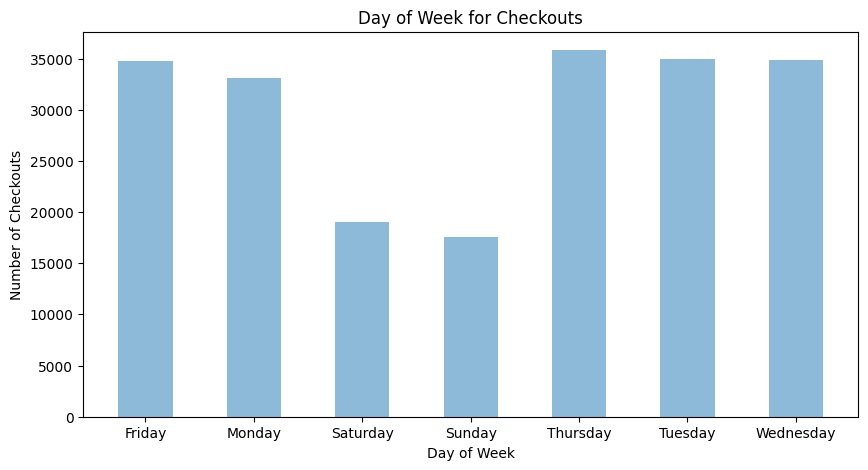

In [34]:
check_out_days = pd.to_datetime(trips['start_date']).dt.day_name()
'''pd.to_datetime() chuyển đổi chuỗi ngày tháng thành đối tượng datetime của pandas,
.dt.day_name() lấy tên đầy đủ của ngày trong tuần từ đối tượng datetime'''

check_out_days_counts = np.unique(check_out_days, return_counts=True)
check_out_days_counts

fig, ax = plt.subplots(1,1, figsize=(10,5))
ax.bar(check_out_days_counts[0], width =0.5, align='center', height=check_out_days_counts[1], alpha=0.5)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Checkouts')
ax.set_title('Day of Week for Checkouts')

plt.show()


### Mục đích sử dụng chủ yếu để di chuyển nhiều hơn là thể thao, giải trí ###
- Lượt checkouts vào cuối tuần ít hơn ngày thường
- Thời gian sử dụng chủ yếu và 8h và 17h: khung giờ đi học, đi làm và giờ tan tầm



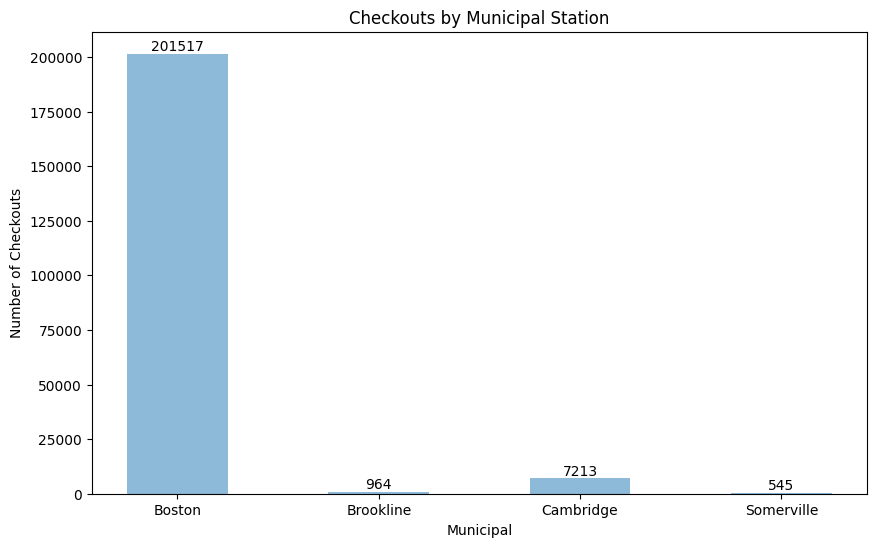

In [35]:
municipal_station= stations.set_index('id')['municipal']
#tạo một Series mới có id làm index và municipal làm giá trị

trips['strt_municipal'] = trips['strt_statn'].map(municipal_station)

municipal_counts = np.unique(trips['strt_municipal'].values, return_counts=True)
# del municipal_station # xóa biến tạm để giải phóng bộ nhớ

fig, ax = plt.subplots(1,1, figsize=(10,6))
ax.bar(municipal_counts[0], width =0.5, height=municipal_counts[1], align = 'center', alpha=0.5)

ax.set_xlabel('Municipal')
ax.set_ylabel('Number of Checkouts')
ax.set_title('Checkouts by Municipal Station')

for i, count in enumerate(municipal_counts[1]):
    ax.text(i, count, str(count), ha='center', va='bottom'
    )
plt.show()


### Thành phố sử dụng nhiều nhất là Boston ###

### DATA MODELLING ###
EDA giúp quan sát dữ liệu, data modelling giúp kiểm tra mối quan hệ phức tạp hơn giữa các đặc trưng.
Ở phần modelling, ta cần đặt ra những câu hỏi phức tạp hơn:
- Nhân khẩu học (đặc điểm người dùng như giới tính, tuổi, mã zip) ảnh hưởng thế nào đến duration?
- Thời tiết ảnh hưởng thế nào đến bike usage?
- Vị trí trạm ảnh hưởng thế nào đến số lượt checkout?
- Khoảng cách từ trung tâm thành phố có làm giảm/tăng usage không?

Những câu này không chỉ hỏi “cái gì nhiều hơn”, mà hỏi: Yếu tố A có ảnh hưởng hoặc liên quan đến kết quả B như thế nào?

Thử trả lời câu hỏi: Khoảng cách từ trung tâm thành phố có liên quan đến số lượt sử dụng xe không?

In [37]:
import importlib 
#thư viện này cho phép bạn tải lại một module đã được import trước đó 
# mà không cần phải khởi động lại toàn bộ chương trình

importlib.reload(helper) 
#tải lại module helper để đảm bảo rằng bất kỳ thay đổi nào trong helper.py 
# cũng được cập nhật khi sử dụng hàm get_distance()

count_df = helper.get_distance()

count_df.head()

,id,checkouts,terminal,station,municipal,lat,lng,status,dist_to_center
0,3.0,1878,B32006,Colleges of the Fenway,Boston,42.340021,-71.100812,Existing,2.335706
1,4.0,3376,C32000,Tremont St. at Berkeley St.,Boston,42.345392,-71.069616,Existing,0.853095
2,5.0,1913,B32012,Northeastern U / North Parking Lot,Boston,42.341814,-71.090179,Existing,1.802423
3,6.0,3616,D32000,Cambridge St. at Joy St.,Boston,42.361285,-71.065140,Existing,0.467803
4,7.0,1384,A32000,Fan Pier,Boston,42.353412,-71.044624,Existing,0.807582


In [38]:
# Let us use a straight line y = ax + b to model the relation
# between the number of checkouts and distance to the city center 
beta0 = 4394 
beta1 = -1175

y_pred = beta0 + beta1 * count_df['dist_to_center'].values

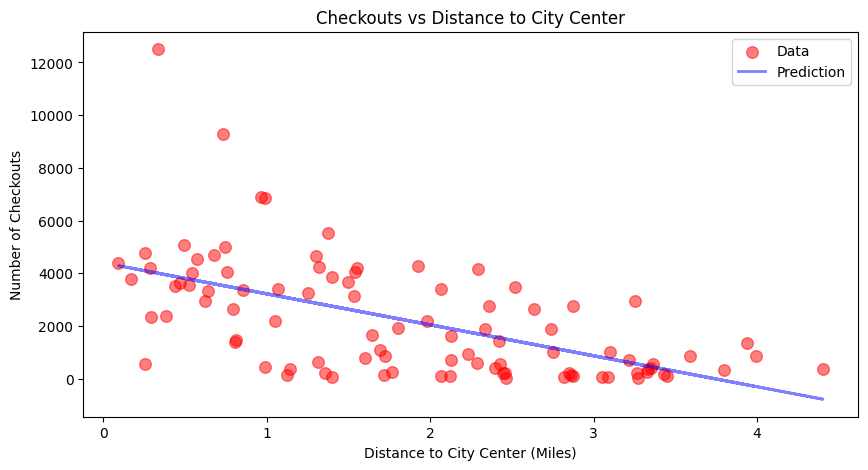

In [39]:
fig, ax = plt.subplots(1,1, figsize=(10,5))
ax.scatter(count_df['dist_to_center'].values, count_df['checkouts'].values, label='Data', s=70, c='red', alpha = 0.5)
ax.plot(count_df['dist_to_center'].values, y_pred, c='blue', label='Prediction', linewidth = 2, alpha = 0.5)
ax.set_xlabel('Distance to City Center (Miles)')
ax.set_ylabel('Number of Checkouts')
ax.set_title('Checkouts vs Distance to City Center')
ax.legend()

### ⏸ Based on our "linear" model, what would most likely be the number of checkouts for a distance of 2.5 miles from the city center?
#### A. 45000
#### B. 12530
#### C. 1450
#### D. 650

là C vì y_pred = 4394 + (-1175) * 2.5 = 1456.5, gần nhất với 1450 trong các lựa chọn